# Chapter 8 - Tree-Based Algorithms and Ensemble Methods

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_8) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Introduction to Decision Trees](#introduction-to-decision-trees)
- [Random Forests and Bagging](#random-forests-and-bagging)
- [Gradient Boosted Machines](#gradient-boosted-machines)
- [Hyperparameter Tuning for Trees and Ensembles](#hyperparameter-tuning-for-trees-and-ensembles)
- [Comparing Ensemble Methods](#comparing-ensemble-methods)
- [Practical Exercises with Tree-Based Models](#practical-exercises-with-tree-based-models)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Introduction to Decision Trees

Decision tree membagi ruang fitur secara rekursif. Klasifikasi memilih split untuk mengurangi impurity, misalnya Gini $1-\sum_k p_k^2$ atau entropy $-\sum_k p_k\log p_k$. Daun menyimpan distribusi kelas; regresi pohon menyimpan respons rata-rata dan meminimalkan variasi target. Kedalaman, minimum ukuran daun, dan cost-complexity pruning membatasi variance.

Pohon tidak membutuhkan scaling seperti KNN, namun rentan perubahan sampel dan overfitting. Diagram Iris membantu membaca aturan, tetapi kemudahan membaca pohon kecil tidak otomatis berlaku bagi pohon besar.

In [2]:
# Load libraries 
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [3]:
# Instantiate the model
clf = DecisionTreeClassifier(random_state=2024)

# Fit the model to the training data
clf.fit(X_train, y_train)

# Generate predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

# Create a classification report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Stylize the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df

iris_tree_accuracy = accuracy

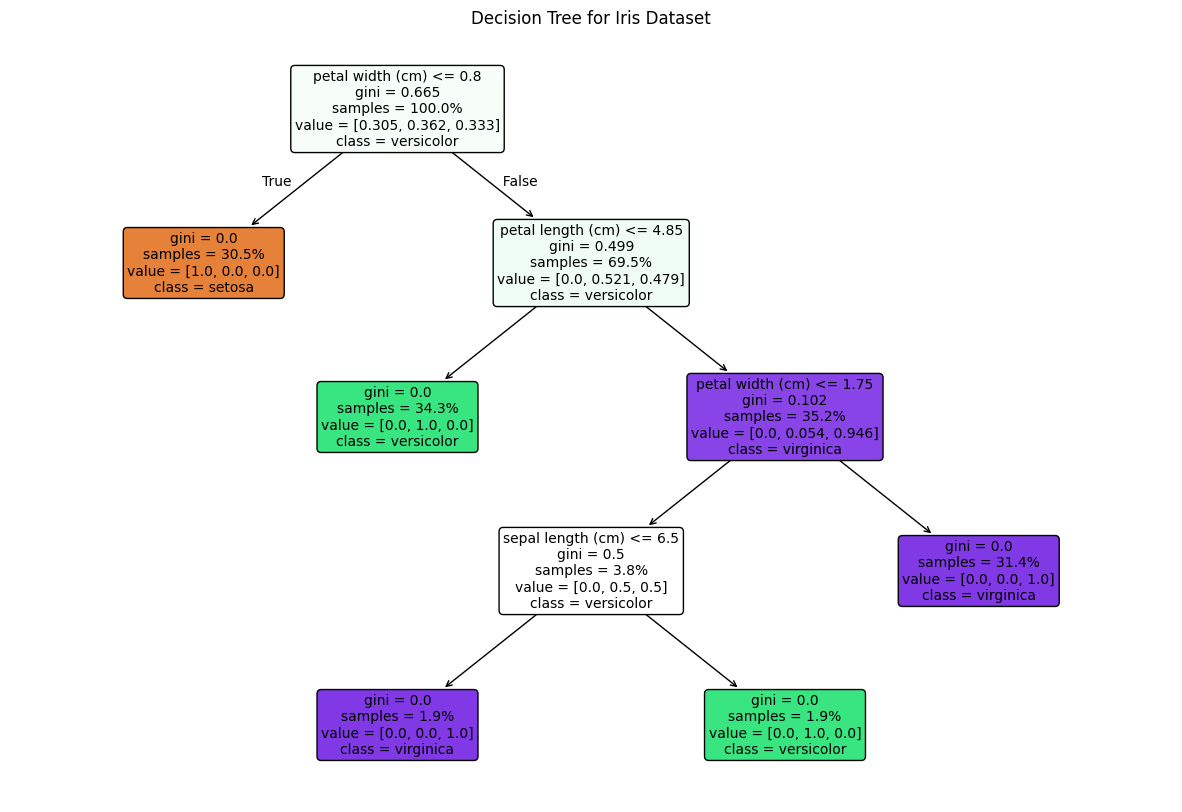

In [4]:
# Load the libraries
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the figure
plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, proportion=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Iris Dataset")
plt.show()

## Random Forests and Bagging

Bagging melatih model pada bootstrap sample lalu menggabungkan prediksi untuk mengurangi variance. Random forest menambah pengacakan subset fitur pada setiap split, sehingga pohon lebih beragam. Untuk klasifikasi scikit-learn, forest merata-ratakan probabilitas kelas tiap pohon sebelum menentukan label. Out-of-bag score dapat memakai pengamatan yang tidak masuk bootstrap pohon terkait, tetapi bukan jaminan bebas dari bias pemilihan model.

Impurity-based feature importance merangkum pengurangan impurity dan dapat bias pada fitur kontinu atau berkardinalitas tinggi. Importance bukan pengaruh kausal; permutation importance pada validation memberi sudut pandang lain dan juga dipengaruhi fitur berkorelasi.

In [5]:
# Load the libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [6]:
# Instantiate the model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)

# Fit the model to the training data
rf_clf.fit(X_train, y_train)

# Generate predictions
y_pred = rf_clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Stylize the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df

iris_rf_accuracy = accuracy

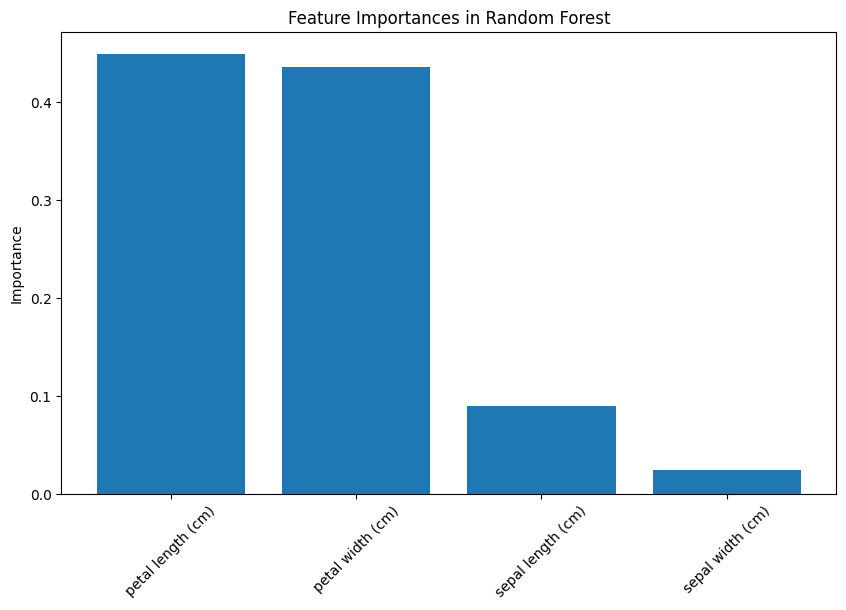

In [7]:
# Load the libraries
import matplotlib.pyplot as plt

# Calculate feature importance
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importance
plt.figure(figsize=(10,6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [iris.feature_names[i] for i in indices], rotation=45)
plt.ylabel("Importance")
plt.show()

iris_importances = importances.copy()

## Gradient Boosted Machines

Boosting membangun model secara bertahap untuk memperbaiki objektif prediksi. Gradient boosting melatih langkah baru pada negative gradient loss; untuk squared error, negative gradient berkaitan dengan residual, sedangkan klasifikasi memakai loss yang berbeda. Learning rate kecil biasanya membutuhkan lebih banyak estimator. Kedalaman, subsample, dan early stopping membantu mengendalikan kompleksitas. AdaBoost memakai pembobotan pengamatan yang berubah sesuai kesalahan.

Konfigurasi 1.000 pohon dan learning rate 0,2 dari sumber dipertahankan sebagai contoh. Konfigurasi itu bukan rekomendasi optimum dan tetap berpotensi overfit.

In [8]:
# Load the libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [9]:
# Instantiate the model
gbm_clf = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.2, random_state=2024)

# Fit the model to the training data
gbm_clf.fit(X_train, y_train)

# Generate predictions
y_pred = gbm_clf.predict(X_test)

# Evaluate the model
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Stylize the DataFrame
styled_df = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_df

iris_boosting_accuracy = accuracy_score(y_test, y_pred)

## Hyperparameter Tuning for Trees and Ensembles

Grid search memvariasikan jumlah estimator, kedalaman, dan learning rate dengan lima fold training. Heatmap menampilkan satu learning rate terbaik dari CV, sehingga tidak mencampur skor dari beberapa learning rate seperti pivot rata-rata sumber. Best score dipengaruhi pencarian hyperparameter; test digunakan setelah fit konfigurasi terpilih.

In [10]:
# Load the libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [11]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Set up GridSearchCV()
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=2024),
                           param_grid,
                           cv=5,
                           scoring='accuracy')

# Fit GridSearchCV() to training data
grid_search.fit(X_train, y_train)

# Identify the best parameters
print(f'Best Parameters: {grid_search.best_params_}')

# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Generate classification report
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# Stylize the DataFrame
styled_df = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

styled_df

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.714,0.833,0.769,12
2,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


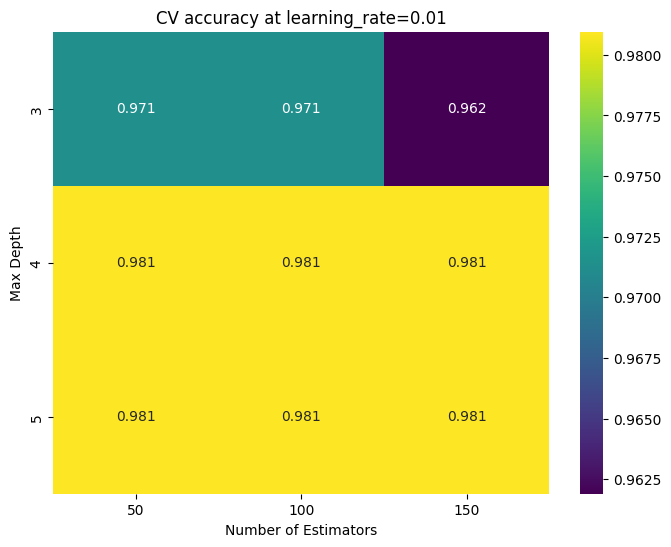

In [12]:
# Load the libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table
results = pd.DataFrame(grid_search.cv_results_)
results = results[results['param_learning_rate'] == grid_search.best_params_['learning_rate']]
pivot_table = results.pivot_table(values='mean_test_score', 
                                  index='param_max_depth', 
                                  columns='param_n_estimators')

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
plt.title(f"CV accuracy at learning_rate={grid_search.best_params_['learning_rate']}")
plt.xlabel('Number of Estimators')
plt.ylabel('Max Depth')
plt.show()

## Comparing Ensemble Methods

Random forest, gradient boosting, dan stacking dibandingkan pada split Iris yang sama. Stacking melatih meta-model dari prediksi out-of-fold base learner, bukan dari prediksi training yang terlalu optimistis. LogisticRegression menjadi meta-model pada contoh.

Bagging terutama mengurangi variance dan boosting dapat memperbaiki bias, tetapi hasil bergantung pada data serta konfigurasi. Skor satu split kecil tidak membuktikan satu ensemble selalu unggul; biaya training/prediksi dan interpretabilitas juga relevan.

In [13]:
# Load the libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [14]:
# Instantiate models
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=2024)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    final_estimator=LogisticRegression(random_state=2024, max_iter=2000),
    cv=5
)
# Fit the models
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

# Generate predictions
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
stacking_pred = stacking_clf.predict(X_test)

# Evaluate the models
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

# Print the accuracy scores
print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.2f}')
print(f'Stacking Accuracy: {stacking_accuracy:.2f}')

iris_stacking_accuracy = stacking_accuracy

Random Forest Accuracy: 0.91
Gradient Boosting Accuracy: 0.87
Stacking Accuracy: 0.87


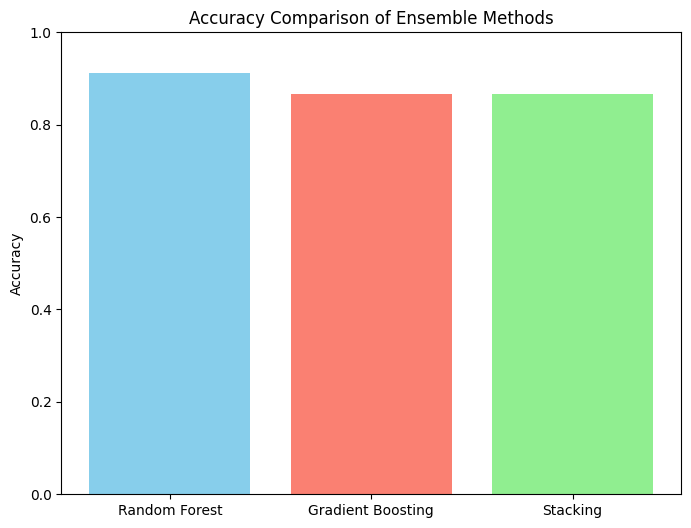

In [15]:
# Load the libraries
import matplotlib.pyplot as plt

# Create a bar plot
methods = ['Random Forest', 'Gradient Boosting', 'Stacking']
accuracies = [rf_accuracy, gb_accuracy, stacking_accuracy]

# Plot the bar plot
plt.figure(figsize=(8, 6))
plt.bar(methods, accuracies, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Accuracy Comparison of Ensemble Methods')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

## Practical Exercises with Tree-Based Models

Tiga latihan mencakup decision tree pada Wine, tuning random forest pada Breast Cancer, serta perbandingan random forest dan gradient boosting pada Digits. Dataset dan split tiap latihan berbeda, sehingga perbandingan skor lintas latihan tidak menjadi ranking universal. Random state ditetapkan agar proses dapat diulang.

### Latihan 1: Building and Evaluating a Decision Tree Classifier

Decision tree Wine menghasilkan report untuk tiga kelas. Model membaca fitur numerik tanpa memerlukan scaling.

In [16]:
# Load libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train the classifier
clf = DecisionTreeClassifier(random_state=2024)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

#Evaluate performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.79      0.95      0.86        20
           2       0.94      0.94      0.94        16

    accuracy                           0.89        54
   macro avg       0.91      0.89      0.89        54
weighted avg       0.90      0.89      0.89        54



### Latihan 2: Hyperparameter Tuning with Random Forests

Random forest Breast Cancer dituning pada jumlah pohon, max_depth, dan max_features. Grid search hanya memakai training; accuracy akhir dihitung pada test.

In [17]:
# Load libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Define hyperparameter grid and perform grid search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'max_features': ['sqrt', 'log2'] 
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=2024), param_grid, cv=5, error_score='raise')
grid_search.fit(X_train, y_train)

# Evaluate the best model
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Accuracy: {accuracy:.2f}')

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 150}
Accuracy: 0.95


### Latihan 3: Comparing Gradient Boosting and Random Forest

Random forest dan gradient boosting memakai Digits serta split yang sama. Perbandingan menunjukkan hasil dua konfigurasi, bukan keunggulan universal salah satu metode.

In [18]:
# Load libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
digits = load_digits()
X = digits.data
y = digits.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train models
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2024)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Make predictions and evaluate
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Gradient Boosting Accuracy: {gb_accuracy:.2f}')

Random Forest Accuracy: 0.97
Gradient Boosting Accuracy: 0.96


## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [19]:
chapter_results = {'iris_tree_accuracy': float(iris_tree_accuracy),
 'iris_rf_accuracy': float(iris_rf_accuracy),
 'iris_boosting_accuracy': float(iris_boosting_accuracy),
 'iris_stacking_accuracy': float(iris_stacking_accuracy),
 'digits_rf_accuracy': float(rf_accuracy), 'digits_boosting_accuracy': float(gb_accuracy)}
assert np.isclose(iris_importances.sum(), 1)
assert all(0 <= value <= 1 for value in chapter_results.values())
print(json.dumps(chapter_results, indent=2))

{
  "iris_tree_accuracy": 0.8666666666666667,
  "iris_rf_accuracy": 0.9111111111111111,
  "iris_boosting_accuracy": 0.8666666666666667,
  "iris_stacking_accuracy": 0.8666666666666667,
  "digits_rf_accuracy": 0.9685185185185186,
  "digits_boosting_accuracy": 0.9648148148148148
}


## Ringkasan Bab

Pada split Iris, decision tree menghasilkan **accuracy 86.67%**, random forest **91.11%**, gradient boosting awal **86.67%**, dan stacking **86.67%**. Konfigurasi boosting awal berbeda dari base learner stacking, sehingga tabel ini menggambarkan contoh yang dijalankan dan bukan eksperimen terkontrol untuk semua hyperparameter.

Pada latihan Digits, random forest menghasilkan **accuracy 96.85%** dan gradient boosting **96.48%**. Ensemble tidak memiliki pemenang universal. Bagging menggabungkan bootstrap learner, boosting membangun langkah bertahap, dan stacking memakai meta-model dari prediksi out-of-fold. Feature importance berbasis impurity bukan sebab-akibat dan dapat bias pada tipe fitur tertentu. Tuning dilakukan pada training/CV; holdout menunjukkan hasil pada split yang tersedia.